In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

df = pd.read_csv(r"C:\Users\Vaish\Desktop\ML LAB DATASETS LOGISTIC REGRESSION\BATCH-6\28_startup_success.csv")



In [11]:
print("------------HEAD---------------")
print(df.head())
print("-----------TAIL-----------------")
print(df.tail())
print("--------------DESCRIBE-----------")
print(df.describe())
print("----------------INFO-------------")
print(df.info())
print("--------------------MISSING VALUES----------------")
print(df.isnull().sum())


------------HEAD---------------
   funding_million_usd  team_size  market_size_score  \
0                36.87      10.16               6.16   
1                19.01      71.74               2.96   
2                21.71      39.68               5.96   
3                12.94       9.95               9.25   
4                 5.09      47.13               6.09   

   founder_experience_years employment_type region marital_status  \
0                     10.03       Full-time   West       Divorced   
1                     10.21       Part-time   East       Divorced   
2                      9.97       Part-time   West         Single   
3                     16.95   Self-employed  North        Married   
4                     23.18      Unemployed  South         Single   

   is_successful  
0              1  
1              0  
2              0  
3              1  
4              1  
-----------TAIL-----------------
     funding_million_usd  team_size  market_size_score  \
295        

In [12]:
X = df.drop("is_successful", axis=1)
y = df["is_successful"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 12)
Testing data: (60, 12)


In [13]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [14]:
z = model.decision_function(X_test)

probability = 1 / (1 + np.exp(-z))

print("Sigmoid probabilities:")
print(probability[:10])

Sigmoid probabilities:
[0.84825695 0.47425904 0.32569316 0.6298016  0.30128491 0.32734983
 0.51826882 0.8444821  0.2798042  0.10574244]


In [15]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("Predicted labels:")
print(y_pred[:10])

print("\nPredicted probabilities:")
print(y_prob[:10])

Predicted labels:
[1 0 0 1 0 0 1 1 0 0]

Predicted probabilities:
[0.84825695 0.47425904 0.32569316 0.6298016  0.30128491 0.32734983
 0.51826882 0.8444821  0.2798042  0.10574244]


In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[23  9]
 [ 8 20]]
Accuracy: 0.7166666666666667
Precision: 0.6896551724137931
Recall: 0.7142857142857143
F1 Score: 0.7017543859649122


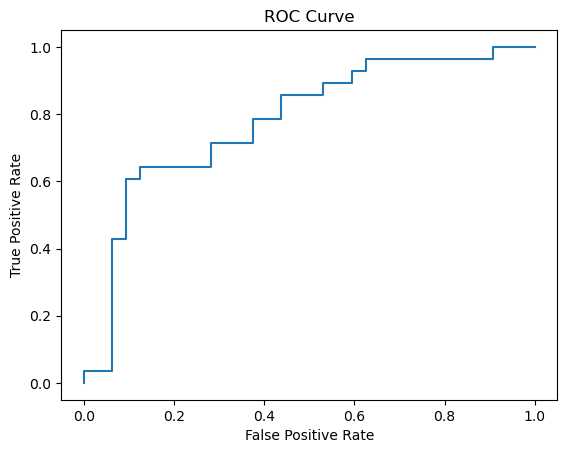

AUC: 0.78125


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", auc)

In [18]:
threshold = 0.7

y_pred_new = (y_prob >= threshold).astype(int)

print("Predictions with threshold 0.7:")
print(y_pred_new[:20])

Predictions with threshold 0.7:
[1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 1 0]


In [19]:
new_data = pd.DataFrame({
    "funding_million_usd": [20],
    "team_size": [30],
    "market_size_score": [75],
    "founder_experience_years": [8],
    "employment_type": ["Full-time"],
    "region": ["North"],
    "marital_status": ["Married"]
})

new_data = pd.get_dummies(new_data, drop_first=True)

new_data = new_data.reindex(columns=X.columns, fill_value=0)

new_probability = model.predict_proba(new_data)[:, 1]
new_prediction = (new_probability >= 0.7).astype(int)

print("Success probability:", new_probability[0])
print("Prediction:", new_prediction[0])

Success probability: 0.9999999956291359
Prediction: 1
